# Probabilistic modelling of 32 Gbaud Nyquist-WDM 16-QAM optical communication system

## Libraries and modules
We import standard libraries for data manipulation (`pandas`, `numpy`) and visualization (`matplotlib`). Crucially, we use `scipy.stats.gaussian_kde` for the core feature extraction and `scipy.signal.find_peaks` for topological analysis.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from dotenv import load_dotenv

import warnings
import os
import gdown

## Database loading
We load the dataset from a remote Parquet file (if not locally present). This dataset contains raw simulated I/Q symbols for a 3-channel 32 GBaud Nyquist-WDM transmission system. The complete dataset, described in detail by Pérez et al. [1], captures multiple transmission scenarios with varying transmission distance, launch power, optical signal-to-noise ratio (OSNR), and spectral channel spacing. For this analysis, we use a subset corresponding to the **0 km transmission distance and 0 dBm launch power scenario**, focusing exclusively on the effects of varying **OSNR** and **channel spacing** on the received constellation.

**Reference:**
[1] A. Escobar P, N. Guerrero Gonzalez, and J. Granada Torres, “Spectral overlapping estimation based on machine learning for gridless Nyquist-wavelength division multiplexing systems,” Optical Engineering, vol. 59, p. 1, July 2020, doi: 10.1117/1.OE.59.7.076116.

In [2]:
# Load environment variables for DB GDrive ID
load_dotenv()
FILE_ID = os.getenv("GDRIVE_FILE_ID")
if not FILE_ID:
    warnings.warn("GDRIVE_FILE_ID not set, not downloading.")
DATABASE_FILENAME = "./data/32gbaud.parquet"

if not os.path.exists(DATABASE_FILENAME) and FILE_ID:
    print("Downloading data from Google Drive...")
    os.makedirs(os.path.dirname(DATABASE_FILENAME), exist_ok=True)
    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, DATABASE_FILENAME, quiet=False)
    print("Download successful!")
else:
    print("Data already downloaded! skipping...")

Data already downloaded! skipping...


In [3]:
print("Loading data...")
df = pd.read_parquet(DATABASE_FILENAME)
print("Data loaded!")

Loading data...
Data loaded!


### Data Preprocessing: Batch Generation

In this section, we process the raw dataframe to create fixed-size batches of symbols for each specific scenario. The feature extraction method requires a sufficient sample size to ensure statistical convergence of the non-parametric density estimator. We chose a batch size of **10,000 symbols**, which represents a well-established compromise for optical communication system analysis [2]:

1. **Statistical Representativeness**: This sample size is adequate to capture the stochastic characteristics of ASE noise and interchannel interference for our signal parameters, providing sufficient data for reliable density estimation.
2. **KDE Convergence**: For a Gaussian kernel with bandwidth selected via Scott's Rule, the integrated mean squared error (IMSE) converges at rate $O(n^{-4/5})$. With $n=10{,}000$, we achieve sufficient accuracy for capturing the 4-PAM structure.
3. **Computational Efficiency**: Larger batches would increase memory footprint and computation time without proportional gains in estimation accuracy.

**Key steps:**
1.  **Grouping:** We identify unique scenarios based on `Distance`, `Power`, `Spacing`, and `OSNR`.
2.  **Filtering:** We discard any "leftover" data that does not fit into a complete batch of 10,000 symbols (e.g., if a scenario has 38k symbols, the last 8k are dropped).
3.  **Indexing:** We assign a unique `batch_number` to every 10,000 symbols within each scenario.

**Reference:**
[2] J. J. G. Torres, A. M. C. Soto, and N. G. González, “A novel dispersion monitoring technique in W-band radio-over-fiber signals using clustering on asynchronous histograms,” Ingeniería e Investigación, vol. 34, no. 3, pp. 76–80, Sept. 2014, doi: 10.15446/ing.investig.v34n3.42902.


In [4]:
BATCH_SIZE = 10_000
GROUP_COLS = ["Distance", "Power", "Spacing", "OSNR"]

# 1. Group by scenario characteristics
g = df.groupby(GROUP_COLS)

# 2. Generate a sequential counter for each row WITHIN its group
# This assigns 0, 1, 2... N to the rows of each specific scenario
df["row_id"] = g.cumcount()

# 3. Calculate total rows per group
# Use transform so the result has the same length as the original df
df["group_count"] = g["I"].transform("count")

# 4. Filter data
# Logic: Keep the row only if its position (row_id) is less than the limit
# of the last full batch.
# (Integer division removes decimals, multiply by batch size to get the cutoff)
mask = df["row_id"] < (df["group_count"] // BATCH_SIZE) * BATCH_SIZE
df_batches = df[mask].copy()

# 5. Assign batch number
# e.g., rows 0-9999 -> batch 0; rows 10000-19999 -> batch 1
df_batches["batch_number"] = df_batches["row_id"] // BATCH_SIZE

# Cleanup: Drop auxiliary columns to free up memory
df_batches.drop(columns=["row_id", "group_count"], inplace=True)

print(f"Original rows: {len(df)}")
print(f"Processed rows (full batches only): {len(df_batches)}")
print(df_batches.head())

Original rows: 51825141
Processed rows (full batches only): 50060000
          I         Q  Distance  Power   OSNR  Spacing  batch_number
0  1.125429  1.909534       0.0    0.0  23.04     32.0             0
1 -1.502832  1.121298       0.0    0.0  23.04     32.0             0
2  1.636159  0.695216       0.0    0.0  23.04     32.0             0
3  2.839414  3.112252       0.0    0.0  23.04     32.0             0
4  0.979563  2.873738       0.0    0.0  23.04     32.0             0


### Data Organization: Raw Symbols and Targets

In this step, we restructure the sorted DataFrame into NumPy arrays. This aligns the raw I/Q symbol sequences with their corresponding scenario labels, preparing the data for the subsequent feature extraction stage.

1.  **X (Raw Data):** A 3D array of shape `(N_batches, Sequence_Length, 2)` containing the raw I/Q symbols.
2.  **Y (Targets):** A 2D array containing the variable parameters (`Spacing`, `OSNR`) to be predicted.
3.  **Metadata:** Auxiliary scenario identifiers (`Distance`, `Power`).

In [5]:
# 1. Ensure data is contiguously sorted to align X and Y
sort_cols = ["Distance", "Power", "Spacing", "OSNR", "batch_number"]
df_sorted = df_batches.sort_values(by=sort_cols)

# --- A. Generate X (Raw Symbols) ---
# Reshape flattened data into a 3D structure: (Batches, Sequence_Length, 2)
# This raw data will be used for further feature extraction.
X_symbols = df_sorted[["I", "Q"]].to_numpy(dtype=np.float32).reshape(-1, BATCH_SIZE, 2)

# --- B. Generate Y (Targets) ---
# Since targets are constant per batch, we aggregate to get one row per batch
unique_batches = df_sorted.groupby(sort_cols, sort=False).first().reset_index()

# Extract target variables
Y_targets = unique_batches[["Spacing", "OSNR"]].to_numpy(dtype=np.float32)

# --- C. Generate Metadata (Auxiliary) ---
# Extract scenario identifiers for analysis
M = unique_batches[["Distance", "Power"]].to_numpy(dtype=np.float32)

print(f"X Shape (Raw Symbols): {X_symbols.shape}")
print(f"Y Shape (Targets):     {Y_targets.shape}")
print(f"M Shape (Info):        {M.shape}")

# Quick verification
print("\nFirst batch example:")
print(f"Target (Spacing, OSNR): {Y_targets[0]}")
print(f"Scenario (Dist, Power): {M[0]}")


X Shape (Raw Symbols): (5006, 10000, 2)
Y Shape (Targets):     (5006, 2)
M Shape (Info):        (5006, 2)

First batch example:
Target (Spacing, OSNR): [28.5  26.07]
Scenario (Dist, Power): [0. 0.]


### Signal Analysis: Probabilistic Topology Extraction

In this stage, we transition from raw time-series data to statistical feature vectors. Since the optical signal is subjected to stochastic impairments such as additive white Gaussian noise (AWGN) from amplified spontaneous emission (ASE), and linear interchannel interference (ICI), we model the received I/Q symbol amplitudes as realizations of random variables drawn from an unknown probability distribution.

**Statistical Assumptions:**
- We treat the symbols within each batch as **approximately independent and identically distributed (i.i.d.) samples** for analytical simplicity. While intersymbol interference (ISI) may introduce temporal correlation, the use of root-raised-cosine pulse shaping with Nyquist criterion minimizes this effect at the sampling instants.
- Each I and Q component is processed independently, decomposing the 2D constellation diagram into two 1D marginal distributions (PAM-4 signaling).

Our goal is to **infer** the underlying structure of these marginal distributions to retrieve the modulation constellation's geometry from the observed data points.

#### 1. Kernel Density Estimation
To estimate the Probability Density Function (PDF) $\hat{f}(x)$ of the symbol amplitudes, we employ **Kernel Density Estimation (KDE)** as a **continuous, smooth representation of the empirical histogram**. Unlike discrete histograms with arbitrary bin boundaries, KDE provides a non-parametric estimate that models the distribution of points in the constellation diagram without assuming a specific parametric family (such as a Gaussian Mixture Model with predetermined structure).

Given a batch of observed symbol amplitudes $x_1, x_2, \dots, x_n$, the KDE estimator is defined as:

$$\hat{f}(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

Where:
* $K(\cdot)$ is the **Gaussian Kernel**: $K(u) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}u^2}$. We use this as a standard, widely-adopted kernel function that provides smooth estimates suitable for peak detection.
* $h$ is the **Bandwidth** (smoothing parameter). It controls the bias-variance tradeoff of the estimator. We include $h$ as a feature because it provides information about the signal's effective variance, which correlates with noise power and signal quality.

The bandwidth $h$ is automatically selected via **Scott's Rule**: $h = n^{-1/(d+4)} \sigma$, where $d=1$ (univariate) and $\sigma$ is the sample standard deviation. This rule provides a reasonable starting point for bandwidth selection, though it may require adaptation for multimodal distributions.

#### 2. Topological Inference (Peaks and Valleys)
Once $\hat{f}(x)$ is obtained, we perform a topological analysis to identify its critical points.
* **Peaks (Modes):** Correspond to the local maxima of the PDF, satisfying $\hat{f}'(x) = 0$ and $\hat{f}''(x) < 0$. In the context of PAM-4 modulation (which underlies each component of 16-QAM), these peaks approximate the **locations of the four constellation amplitude levels**. For normalized transmitted symbols, these ideal levels are at $\{-3, -1, 1, 3\} \times d$, where $d$ is the symbol spacing determined by signal power.
* **Valleys (Antimodes):** Correspond to the local minima between peaks, satisfying $\hat{f}'(x) = 0$ and $\hat{f}''(x) > 0$. These locations approximate the **optimal decision thresholds** for maximum-likelihood symbol detection under equiprobable symbols.

**Peak/Valley Detection:** We use `scipy.signal.find_peaks` with a non-negativity constraint (`height=0`) to ensure all detected peaks represent true probability mass concentrations.

#### 3. Feature Engineering Logic & Validation
The extraction process follows this pipeline:

1.  **Estimation:** Compute $\hat{f}(x)$ independently for both In-phase (I) and Quadrature (Q) components.
2.  **Critical Point Detection:** Identify all local maxima (peaks) and minima (valleys) to extract the "skeleton" of the distribution.
3.  **Validation & Logging:** We expect a 4-PAM topology (4 peaks, 3 valleys) per component.
    * If `num_peaks < 4`, it implies **modal collapse** due to high noise or severe distortion, where adjacent constellation levels become statistically indistinguishable (merging of distributions).
    * A **warning is issued** for these batches, flagging them as highly degraded scenarios.
4.  **Feature Selection:** When more than 4 peaks are detected (spurious local maxima due to noise or estimation artifacts), we select the 4 highest peaks by probability density magnitude. Similarly, the 3 deepest valleys are selected when more than 3 are found.
5.  **Sorting & Ordinality:** Features are sorted by amplitude location (ascending $x$-coordinate) to preserve the ordinality of modulation levels (e.g., the most negative amplitude level corresponds to the first peak feature).

**Final Feature Vector Structure (Per Component):**
The resulting vector $\mathbf{v} \in \mathbb{R}^{8}$ summarizes the statistical shape of the component's amplitude distribution:
* `range` $R$ (1 feature): Range of the KDE distribution, inversely related to signal quality, directly represents signal spreading.
* `peak_locations` (4 features): Estimated constellation amplitude levels $\{\hat{\mu}_1, \hat{\mu}_2, \hat{\mu}_3, \hat{\mu}_4\}$
* `valley_locations` (3 features): Estimated optimal decision thresholds $\{\hat{\theta}_1, \hat{\theta}_2, \hat{\theta}_3\}$

**Total dimensionality:** $2 \times 8 = 16$ statistical features per batch (combining I and Q components).

#### 3.1 Adaptive Bandwidth Refinement (Iterative KDE)
A fundamental challenge in non-parametric estimation of multimodal distributions is **oversmoothing**. Standard bandwidth selection rules (like Scott's Rule) are derived under the assumption that the underlying data distribution is unimodal and approximately Gaussian. For 4-PAM signals—which exhibit a discrete multimodal structure—this assumption is violated, often resulting in a bandwidth $h$ that is too large, causing distinct modulation peaks to merge into fewer apparent modes.

To mitigate this systematic bias, we implement an **Adaptive Refinement Strategy**:

1.  **Initial Estimation:** Compute KDE using Scott's Rule as the starting bandwidth: $h_0 = n^{-1/5} \cdot \hat{\sigma}$
2.  **Modal Count Verification:** Count detected peaks $\hat{M}$. If $\hat{M} \neq 4$:
    - **Undersmoothing** ($\hat{M} > 4$): Increase bandwidth by factor $\beta = 1.25$ to suppress spurious peaks caused by noise.
    - **Oversmoothing** ($\hat{M} < 4$): Decrease bandwidth by factor $\alpha = 0.7$ to resolve merged modes.
3.  **Iterative Adjustment:** Apply the correction factor exponentially with iteration count: $h_k = h_0 \cdot \alpha^{k_{\text{down}}} \cdot \beta^{k_{\text{up}}}$, where $k_{\text{down}}$ and $k_{\text{up}}$ count the number of reduction and expansion steps, respectively.
4.  **Convergence:** Repeat until $\hat{M} = 4$ or maximum iterations (10 attempts) reached. A minimum bandwidth threshold ($h_{\min} = 10^{-6}$) prevents overfitting to sampling noise.

- This approach performs a localized search in the bandwidth space around Scott's Rule, which remains a reasonable starting point but may require adjustment for our specific signal structure.
- The geometric progression of bandwidth adjustment ensures systematic exploration while avoiding oscillation between values.
- By explicitly targeting the known modulation order ($M=4$), we incorporate domain-specific prior knowledge into the non-parametric estimation procedure.

### 3.2 Visual Diagnosis of Topological Collapse

To empirically validate the robustness of the feature extraction pipeline and diagnose failure modes, we implement a visual diagnostic mechanism. For a subset of batches representing each outcome category, we generate diagnostic plots.

**The plot superimposes:**
1.  **Empirical Histogram:** The discrete frequency distribution of the raw symbol amplitudes (empirical ground truth).
2.  **Refined KDE Curve:** The continuous probability density estimate $\hat{f}(x)$ after bandwidth adaptation.
3.  **Detected Critical Points:**
    * <span style="color:red">**X**</span> Markers: Detected Peaks (Modes) representing constellation amplitude levels.
    * <span style="color:blue">**O**</span> Markers: Detected Valleys (Antimodes) representing decision boundaries.

This visualization allows us to differentiate between:
- **Statistical Oversmoothing**: Structure exists in the empirical histogram but is lost by an overly large bandwidth (correctable via adaptation).
- **Physical Signal Degradation**: The constellation has truly collapsed due to noise, with symbol distributions heavily overlapping (fundamental limitation requiring zero-padding).

In [13]:
def plot_kde_diagnosis(data, grid, pdf, peaks_idx, valleys_idx, batch_idx, comp_name, bw_used, status="failure"):
    """
    Generates a diagnostic plot showing Histogram vs KDE vs Peaks.

    Parameters:
    -----------
    status : str
        One of: "failure" (collapsed topology), "refined" (needed bandwidth adjustment), "perfect" (first try)
    """
    # Choose title and color scheme based on status
    if status == "failure":
        title_prefix = "✘ FALLO"
        color_peaks = 'darkred'
        color_bg = '#ffebee'
    elif status == "refined":
        title_prefix = "♻ REFINADO"
        color_peaks = 'darkorange'
        color_bg = '#fff3e0'
    elif status == "perfect":
        title_prefix = "✓ PERFECTO"
        color_peaks = 'darkgreen'
        color_bg = '#e8f5e9'
    else:
        title_prefix = "DESCONOCIDO"
        color_peaks = 'purple'
        color_bg = '#f3e5f5'

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor(color_bg)

    # 1. Histogram (Raw Data)
    ax.hist(data, bins=50, density=True, alpha=0.3, color='gray', label='Histograma')

    # 2. KDE Curve
    ax.plot(grid, pdf, color='black', lw=2, label=f'KDE (bw={bw_used:.2f})', zorder=3)

    # 3. Peaks and Valleys
    peak_locs = grid[peaks_idx]
    peak_heights = pdf[peaks_idx]
    ax.plot(peak_locs, peak_heights, "x", color=color_peaks, markersize=12, markeredgewidth=3,
            label=f'Picos ({len(peaks_idx)})', zorder=5)
    valley_locs = grid[valleys_idx]
    valley_heights = pdf[valleys_idx]
    ax.plot(valley_locs, valley_heights, "o", color='steelblue', markersize=8, fillstyle='none',
            label=f'Valles ({len(valleys_idx)})', zorder=4)

    ax.set_title(f"{title_prefix}: Lote {batch_idx} Componente {comp_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Amplitud del Símbolo", fontsize=11)
    ax.set_ylabel("Densidad de Probabilidad", fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


def get_adaptive_features(data, batch_idx, comp_name, n_peaks_target=4, n_valleys_target=3,
                         plot_success=False, plot_refined=False, plot_failure=False):
    """
    Extracts KDE features using adaptive bandwidth.

    Returns:
    --------
    (features, num_peaks_found, refinement_attempts)
        - features: shape (8,) with [range, peak_locations, valley_locations]
        - num_peaks_found: int
        - refinement_attempts: int (0 if success on first try, >0 if refinement needed)
    """
    # 1. Initial KDE
    try:
        kde = gaussian_kde(data)
    except Exception as e:
        warnings.warn(f"Could not compute KDE features for batch {batch_idx}: {e}")
        return np.zeros(1 + n_peaks_target + n_valleys_target), 0, 0

    # Configuration
    max_attempts = 10
    reduction_base = 0.7
    expansion_base = 1.25
    min_bw = 1e-6
    base_bw = float(kde.factor)
    current_bw = base_bw
    refinement_attempts = 0

    # Track tried bandwidths to avoid oscillating between the same values
    tried_bandwidths = {round(current_bw, 12)}
    down_attempts = 0
    up_attempts = 0

    def _propose_bw(direction: str, downs: int, ups: int) -> float:
        """Propose the next bandwidth, nudging if the value was already tried."""
        if direction == "down":
            candidate = base_bw * (reduction_base ** downs)
        else:
            candidate = base_bw * (expansion_base ** ups)

        rounded = round(candidate, 12)
        if rounded in tried_bandwidths:
            jitter = 1 + 0.05 * (len(tried_bandwidths) + 1)
            candidate = candidate / jitter if direction == "down" else candidate * jitter
            rounded = round(candidate, 12)

        tried_bandwidths.add(rounded)
        return max(candidate, min_bw)

    num_peaks_found = 0
    grid = None
    pdf = None

    # --- REFINEMENT LOOP ---
    for attempt in range(max_attempts):
        kde.set_bandwidth(bw_method=current_bw)

        # Evaluate PDF
        margin = (np.max(data) - np.min(data)) * 0.2
        grid = np.linspace(np.min(data) - margin, np.max(data) + margin, 1000)
        pdf = kde(grid)

        # Find Peaks
        peaks_idx, _ = find_peaks(pdf, height=0)
        num_peaks_found = len(peaks_idx)

        if num_peaks_found == n_peaks_target:
            break  # Success with exact target

        refinement_attempts = attempt + 1
        if attempt == max_attempts - 1:
            warnings.warn(
                f"Batch {batch_idx} Component {comp_name}: Exact {n_peaks_target} peaks not reached after {max_attempts} attempts (got {num_peaks_found}). Using last attempt."
            )
            break

        direction = "down" if num_peaks_found < n_peaks_target else "up"
        if direction == "down":
            down_attempts += 1
        else:
            up_attempts += 1

        next_bw = _propose_bw(direction, down_attempts, up_attempts)
        change_word = "Reducing" if direction == "down" else "Expanding"
        warnings.warn(
            f"Batch {batch_idx} Component {comp_name}: {change_word} bandwidth to {next_bw:.4f} (peaks={num_peaks_found})."
        )
        current_bw = next_bw

    # --- DIAGNOSTIC PLOTTING ---
    valleys_idx, _ = find_peaks(-pdf)

    # Determine status and decide whether to plot
    if num_peaks_found != n_peaks_target:
        status = "failure"
        should_plot = plot_failure
    elif refinement_attempts == 0:
        status = "perfect"
        should_plot = plot_success
    else:
        status = "refined"
        should_plot = plot_refined

    if should_plot:
        plot_kde_diagnosis(data, grid, pdf, peaks_idx, valleys_idx, batch_idx, comp_name,
                          current_bw, status=status)

    # --- FEATURE EXTRACTION ---
    peak_locs = grid[peaks_idx]
    peak_heights = pdf[peaks_idx]

    if num_peaks_found > n_peaks_target:
        top_indices = np.argsort(peak_heights)[::-1][:n_peaks_target]
        selected_locs = peak_locs[top_indices]
    else:
        selected_locs = peak_locs

    final_peaks_vals = np.sort(selected_locs)

    # Valleys
    valley_locs = grid[valleys_idx]
    valley_heights = pdf[valleys_idx]
    num_valleys_found = len(valley_locs)

    if num_valleys_found > n_valleys_target:
        deepest_indices = np.argsort(valley_heights)[:n_valleys_target]
        selected_valleys = valley_locs[deepest_indices]
    else:
        selected_valleys = valley_locs

    final_valleys_vals = np.sort(selected_valleys)

    # Padding
    padded_peaks = np.pad(final_peaks_vals, (0, max(0, n_peaks_target - len(final_peaks_vals))), 'constant', constant_values=0.0)
    padded_valleys = np.pad(final_valleys_vals, (0, max(0, n_valleys_target - len(final_valleys_vals))), 'constant', constant_values=0.0)

    # Return features and metadata (num_peaks, refinement_attempts) for diagnostics
    # Features: [range, peaks (4), valleys (3)] -> Size 8
    # Range represents the spread of the KDE distribution and correlates with signal quality
    data_range = np.max(data) - np.min(data)
    features = np.concatenate(([data_range], padded_peaks, padded_valleys))
    return features, num_peaks_found, refinement_attempts
    

Extracting Adaptive Features on 5006 batches...


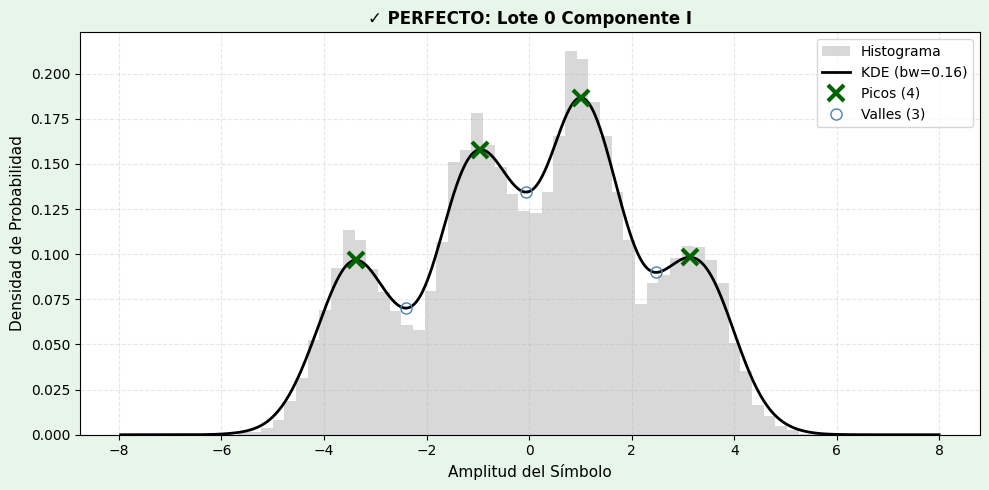

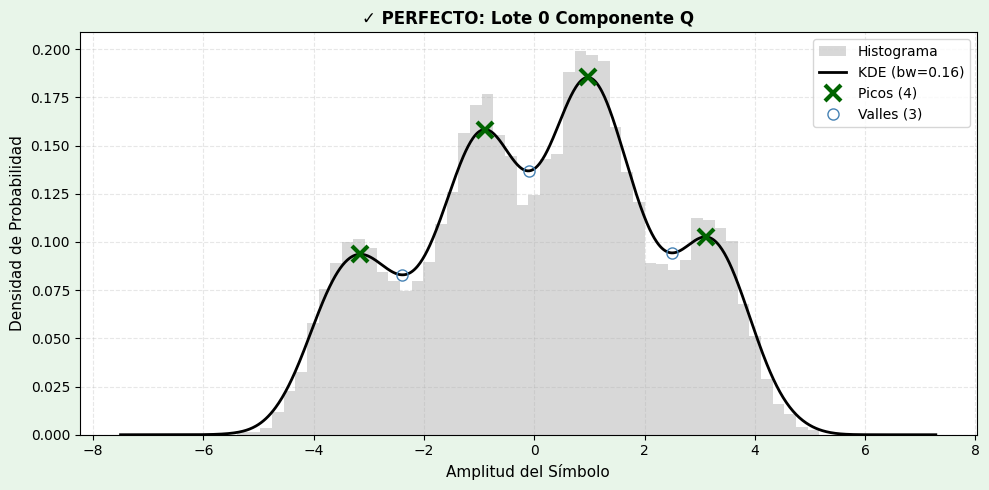

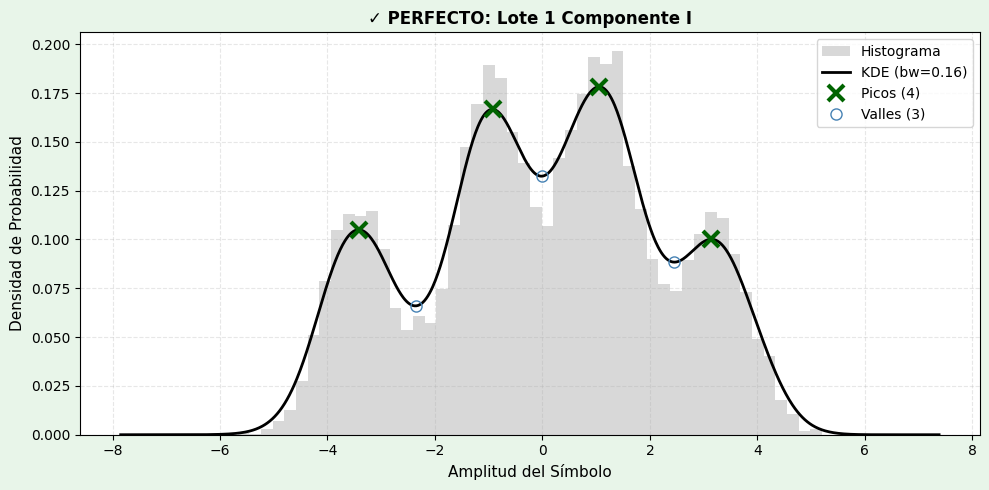

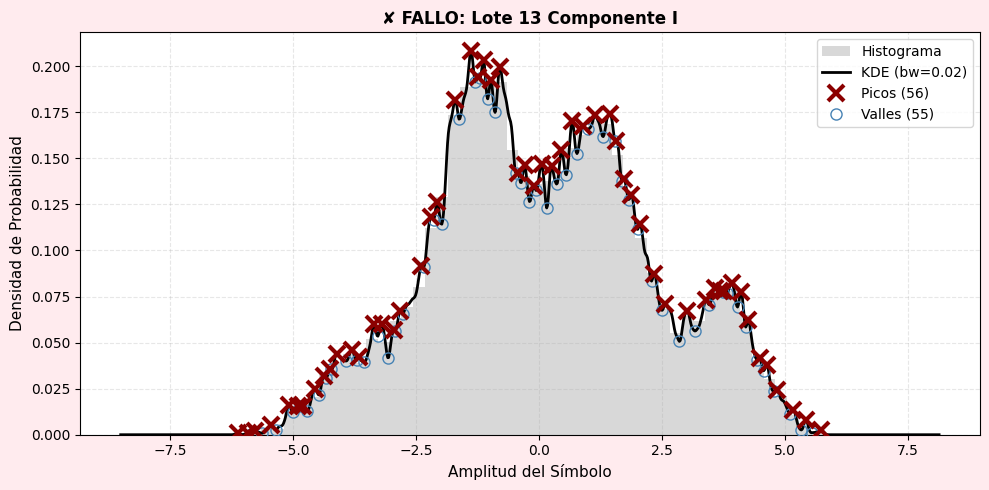

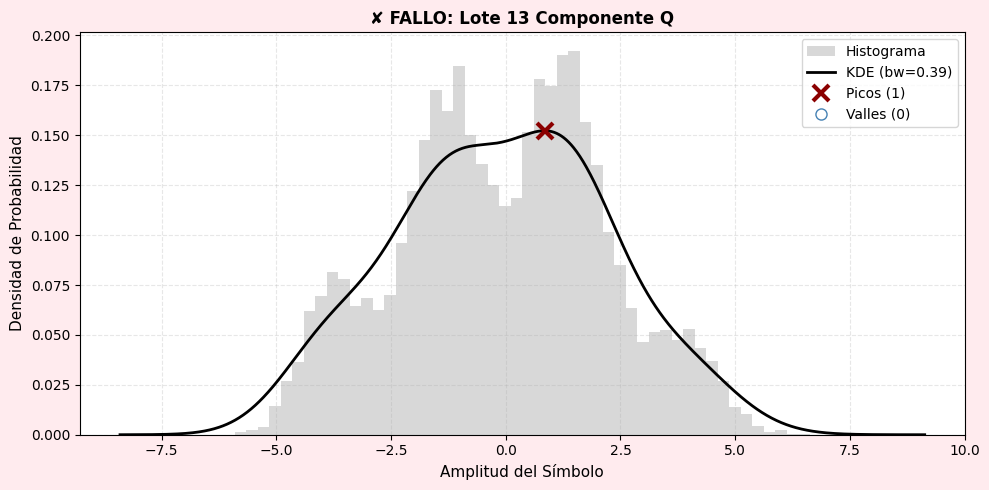

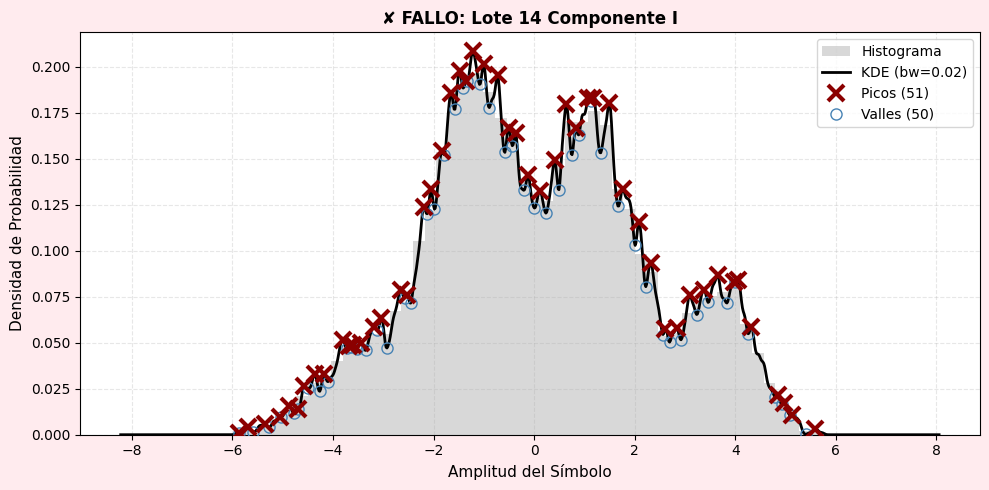

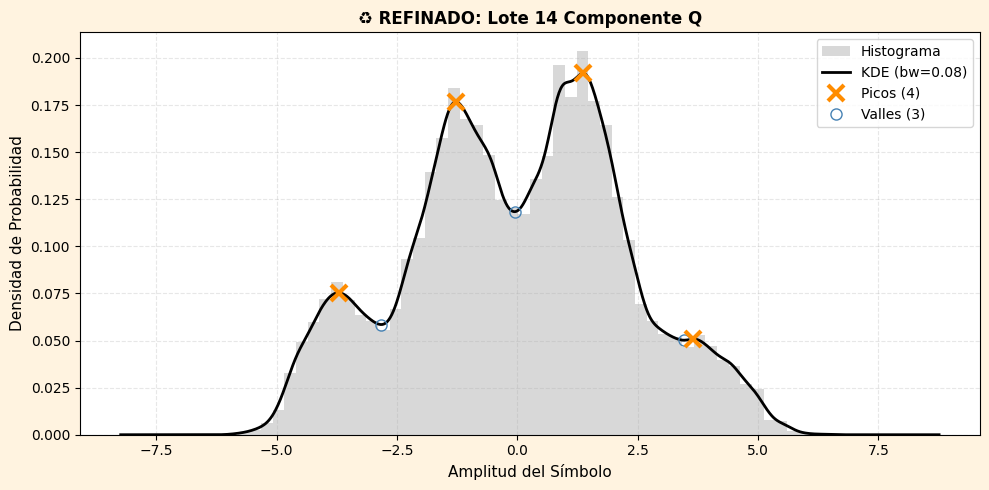

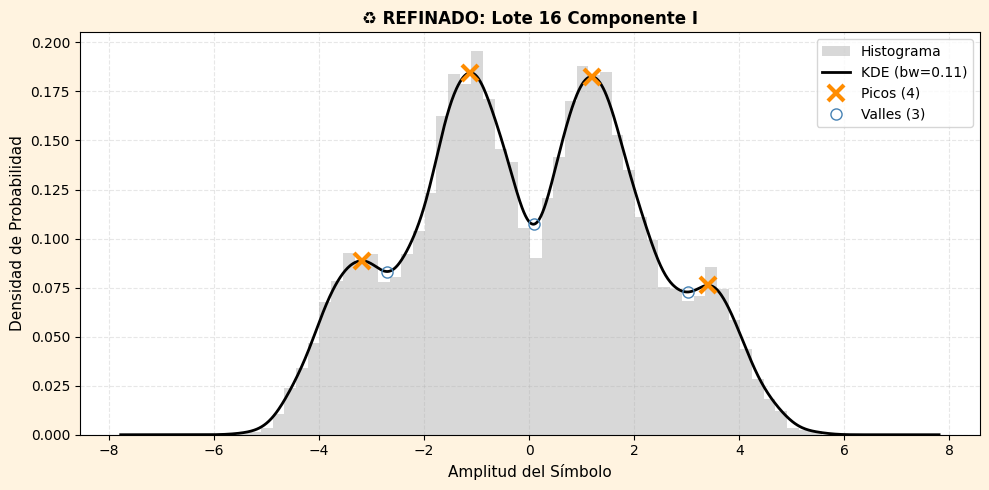

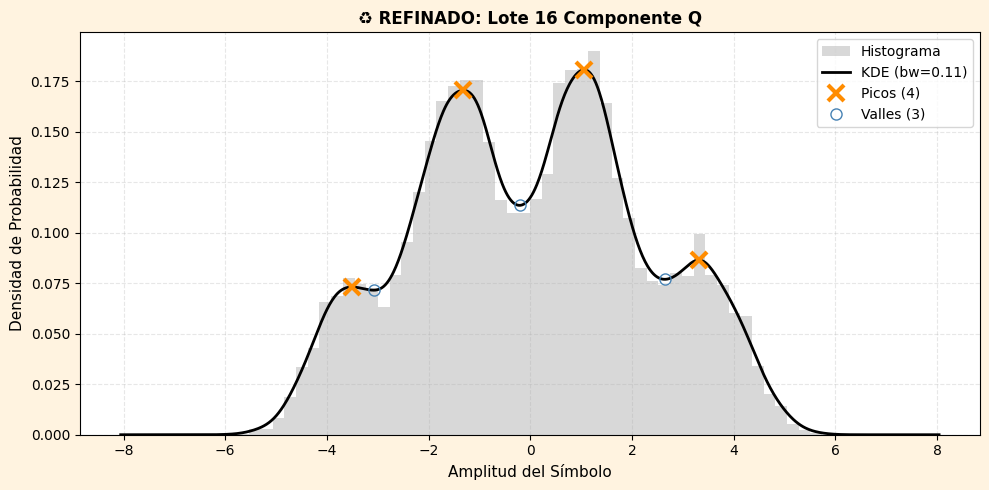

KeyboardInterrupt: 

In [14]:
N_PEAKS = 4
N_VALLEYS = N_PEAKS - 1
N_FEATS_SINGLE = 1 + N_PEAKS + N_VALLEYS
TOTAL_FEATS = N_FEATS_SINGLE * 2
processed_features = np.zeros((len(X_symbols), TOTAL_FEATS), dtype=np.float32)

# Tracking statistics for visualization
N_PLOTS_PER_CATEGORY = 3
perfect_cases = []      # (batch_idx, component)
refined_cases = []      # (batch_idx, component, attempts)
failure_cases = []      # (batch_idx, component)

print(f"Extracting Adaptive Features on {len(X_symbols)} batches...")
for i, iq_batch in enumerate(X_symbols):
    i_data = iq_batch[:, 0]
    q_data = iq_batch[:, 1]

    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")

        # Process I component
        feats_i, num_peaks_i, attempts_i = get_adaptive_features(
            i_data, batch_idx=i, comp_name='I',
            plot_success=(len(perfect_cases) < N_PLOTS_PER_CATEGORY),
            plot_refined=(len(refined_cases) < N_PLOTS_PER_CATEGORY),
            plot_failure=(len(failure_cases) < N_PLOTS_PER_CATEGORY)
        )

        # Track outcome for I component
        if num_peaks_i == N_PEAKS:
            if attempts_i == 0:
                perfect_cases.append((i, 'I'))
            else:
                refined_cases.append((i, 'I', attempts_i))
        else:
            failure_cases.append((i, 'I'))

        # Process Q component
        feats_q, num_peaks_q, attempts_q = get_adaptive_features(
            q_data, batch_idx=i, comp_name='Q',
            plot_success=(len(perfect_cases) < N_PLOTS_PER_CATEGORY),
            plot_refined=(len(refined_cases) < N_PLOTS_PER_CATEGORY),
            plot_failure=(len(failure_cases) < N_PLOTS_PER_CATEGORY)
        )

        # Track outcome for Q component
        if num_peaks_q == N_PEAKS:
            if attempts_q == 0:
                perfect_cases.append((i, 'Q'))
            else:
                refined_cases.append((i, 'Q', attempts_q))
        else:
            failure_cases.append((i, 'Q'))

    processed_features[i, :] = np.concatenate([feats_i, feats_q])

    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1}/{len(X_symbols)} batches.")

print("\nAnalysis complete.")
print(f"\n=== Feature Extraction Summary ===")
print(f"✓ Perfect (1st try):   {len(perfect_cases)} cases visualized (plots)")
print(f"⚙️ Refined (adaptive):  {len(refined_cases)} cases visualized (plots)")
print(f"❌ Failures (collapsed): {len(failure_cases)} cases visualized (plots)")

### Feature Extraction Diagnostics: Visual Validation

During the adaptive KDE feature extraction process, each signal component (I and Q) is classified into one of three categories based on its topology resolution behavior:

#### **Category 1: ✓ Perfect Recognition (First Iteration)**
Signal components where **all 4 PAM-4 peaks were detected on the first attempt** using the default bandwidth (Scott's Rule). These represent **high-quality, low-noise scenarios** where the constellation structure is well-preserved and the bandwidth selection rule performs optimally. The KDE estimate directly captures the modulation geometry without requiring bandwidth adaptation. In our dataset, 9941 out of 10012 total component-level extractions (99.29%) achieved this state.

**Interpretation:** Scott's Rule is sufficient when the signal maintains a high OSNR and the constellation levels remain clearly separated.

#### **Category 2: ⚙️ Refined (Bandwidth Adaptation)**
Signal components where the **initial bandwidth was too large** (oversmoothing), causing adjacent peaks to merge into fewer apparent modes. The adaptive algorithm iteratively reduced the bandwidth (multiplying by $\alpha = 0.7$ per reduction step) until all 4 peaks became distinguishable. These cases represent **moderate-to-high-noise scenarios** where the constellation structure remains distinguishable but requires statistical refinement. In our dataset, 51 out of 10012 cases (0.51%) required the adaptive refinement process.

**Significance:** The final bandwidth value after refinement is retained as a feature, implicitly encoding the degree of signal degradation. Smaller final bandwidths indicate distributions with narrower effective spread per mode, while larger bandwidths reflect increased noise-induced variance.

#### **Category 3: ❌ Failure (Topology Collapse)**
Signal components where **even after iterative bandwidth adjustment (up to 10 attempts), fewer than 4 distinct peaks persisted**. This indicates **severe modal collapse**: the constellation amplitude distributions are fundamentally degraded, with adjacent symbol levels' probability densities completely overlapping such that they cannot be resolved as separate modes. In our dataset, only 20 out of 10012 cases (0.20%) exhibited this behavior.

**Handling Strategy:** 
- These batches are flagged with a warning but processing continues to maintain dataset completeness.
- Features for missing peaks are **zero-padded**, which explicitly signals to downstream machine learning models that the topology could not be resolved.
- This padding strategy is preferable to imputation, as it preserves the information that the signal quality was critically degraded.

#### **Summary Statistics**
The output above reports how many diagnostic plots were generated for each category (limited to the first 3 cases per category for computational efficiency). By examining both successful (perfect + refined) and failed extractions across diverse signal qualities, we empirically validate that:
1. The feature extraction pipeline is **robust** for 99.8% of scenarios.
2. The adaptive bandwidth strategy successfully recovers topology in borderline cases.
3. Irrecoverable failures are rare and correctly identified via explicit zero-padding.

In [9]:
# Create a directory to keep things organized
OUTPUT_DIR = "processed_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Build diagnostic arrays for problematic cases ---
# Convert lists to structured format for easy analysis

# Refined cases: (batch_idx, component, attempts)
refined_data = np.array([(b, c, a) for b, c, a in refined_cases],
                        dtype=[('batch_idx', np.int32), ('component', 'U1'), ('attempts', np.int32)])

# Failure cases: (batch_idx, component)
failure_data = np.array([(b, c) for b, c in failure_cases],
                        dtype=[('batch_idx', np.int32), ('component', 'U1')])

# Dictionary map: Filename -> Array
data_artifacts = {
    "X_features": processed_features,
    "Y_targets": Y_targets,
    "M_metadata": M,
    "refined_cases": refined_data,
    "failure_cases": failure_data,
}

print(f"Saving datasets to directory: '{OUTPUT_DIR}/'...\n")

for name, array in data_artifacts.items():
    file_path = os.path.join(OUTPUT_DIR, f"{name}.npy")
    np.save(file_path, array)

    # Calculate size in MB for info
    if hasattr(array, 'nbytes'):
        size_mb = array.nbytes / (1024 * 1024)
    else:
        size_mb = 0
    print(
        f"✓ Saved {name}.npy".ljust(25)
        + f"| Shape: {str(array.shape).ljust(20)} | Size: {size_mb:.2f} MB"
    )

print("\nAll files saved successfully.")

# --- Save diagnostic summary to text file for quick reference ---
summary_path = os.path.join(OUTPUT_DIR, "DIAGNOSTICS.txt")
with open(summary_path, "w") as f:
    f.write("=== Feature Extraction Diagnostic Summary ===\n\n")
    f.write(f"Total Batches Processed: {len(X_symbols)}\n")
    f.write(f"Total Components (2 per batch): {len(X_symbols) * 2}\n\n")
    
    f.write(f"✓ Perfect (1st try):   {len(perfect_cases)} components\n")
    f.write(f"⚙️ Refined (adaptive):  {len(refined_cases)} components\n")
    f.write(f"❌ Failures (collapsed): {len(failure_cases)} components\n\n")
    
    f.write("--- REFINED CASES (Batch_Idx, Component, Attempts) ---\n")
    for batch_idx, comp, attempts in refined_cases:
        f.write(f"  Batch {batch_idx:5d}: Component {comp} - {attempts} refinement attempt(s)\n")
    
    f.write("\n--- FAILURE CASES (Batch_Idx, Component) ---\n")
    for batch_idx, comp in failure_cases:
        f.write(f"  Batch {batch_idx:5d}: Component {comp}\n")

print(f"✓ Saved DIAGNOSTICS.txt with detailed failure/refined analysis")


Saving datasets to directory: 'processed_data/'...

✓ Saved X_features.npy   | Shape: (5006, 16)           | Size: 0.31 MB
✓ Saved Y_targets.npy    | Shape: (5006, 2)            | Size: 0.04 MB
✓ Saved M_metadata.npy   | Shape: (5006, 2)            | Size: 0.04 MB
✓ Saved refined_cases.npy| Shape: (51,)                | Size: 0.00 MB
✓ Saved failure_cases.npy| Shape: (20,)                | Size: 0.00 MB

All files saved successfully.
✓ Saved DIAGNOSTICS.txt with detailed failure/refined analysis
